Current step: 9999

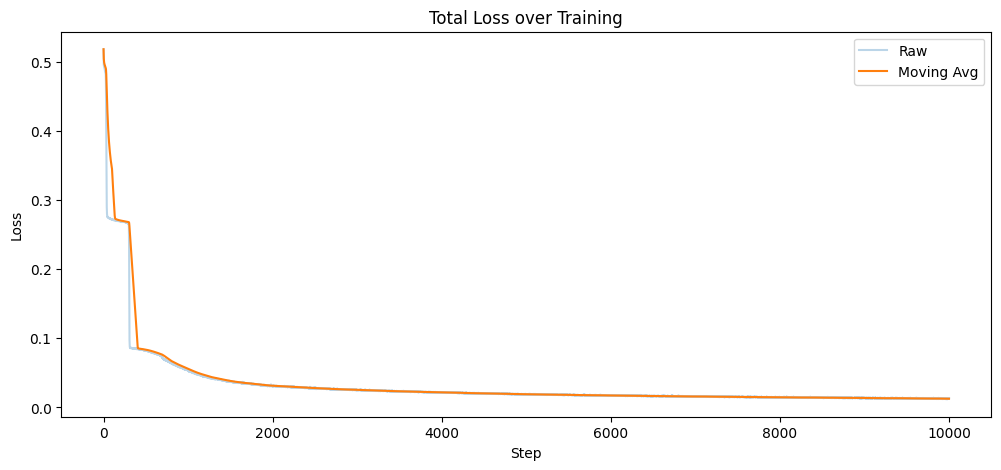

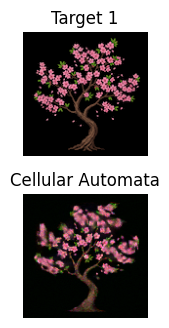

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
from IPython import display
import os
from typing import List, Tuple
import sys
import csv

# Constants
FIRE_RATE = 0.5
HIDDEN_CHANNELS = 128
BATCH_SIZE = 1
MOVING_AVG_WINDOW = 100
TARGET_WEIGHT = 1

TARGET_PATHS = [
    ('NCA_128.png', 128, 1)
]

CHECKPOINT_PATH = None
START_STEP = 0
NUM_STEPS = 10000   # total number of training steps

# Parameterize the folder where models are saved and loaded from
MODEL_SAVE_FOLDER = 'train_log_r128_hc128_fr5'
os.makedirs(MODEL_SAVE_FOLDER, exist_ok=True)

def preprocess_image(image_path):
    img = Image.open(image_path).convert('RGBA')
    data = img.getdata()
    new_data = []
    for item in data:
        if item[0] < 25 and item[1] < 25 and item[2] < 25:
            new_data.append((0, 0, 0, 0))
        else:
            new_data.append(item)
    img.putdata(new_data)
    return transforms.ToTensor()(img)

def load_targets(target_paths: List[Tuple[str, int, int]], device):
    target_paths.sort(key=lambda x: x[1])
    target_tensors = [preprocess_image(p).to(device) for p, _, _ in target_paths]
    target_steps = [s for _, s, _ in target_paths]
    target_durations = [d for _, _, d in target_paths]
    H, W = target_tensors[0].shape[1:]
    for t in target_tensors:
        assert t.shape[1:] == (H, W), "All target images must have the same dimensions"
    return target_tensors, target_steps, target_durations, H, W

class CAModel(nn.Module):
    def __init__(self, hidden_channels=HIDDEN_CHANNELS):
        super().__init__()
        self.hidden_channels = hidden_channels
        identify = torch.tensor([0.0, 1.0, 0.0])
        identify = torch.outer(identify, identify)
        dx = torch.outer(torch.tensor([1.0,2.0,1.0]), torch.tensor([-1.0,0.0,1.0]))/8.0
        dy = dx.T
        self.register_buffer('kernel', torch.stack([identify, dx, dy]).unsqueeze(1))
        self.update = nn.Sequential(
            nn.Conv2d(hidden_channels*3, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
        )
    def perceive(self, x):
        k = self.kernel.repeat(1, self.hidden_channels, 1, 1)
        k = k.reshape(self.hidden_channels*3, 1, 3, 3)
        return F.conv2d(x, k, padding=1, groups=self.hidden_channels)
    def forward(self, x):
        y = self.perceive(x)
        dx = self.update(y)
        mask = (torch.rand_like(x) < FIRE_RATE).float()
        x = x + dx * mask
        return torch.clamp(x, 0.0, 1.0)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = CAModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.8, patience=500
)

# resume from checkpoint if available
current_step = START_STEP
if CHECKPOINT_PATH and os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    current_step = ckpt['step']
    print(f"Resuming from step {current_step}")

# load targets
target_tensors, target_steps, target_durations, H, W = load_targets(TARGET_PATHS, device)
num_targets = len(target_tensors)

# manually initialize seed tensor
seed_tensor = torch.zeros(4, H, W, device=device)
center_y, center_x = H // 2, W // 2
seed_tensor[:, center_y, center_x] = 1.0

# Prepare CSV logging
csv_path = os.path.join(MODEL_SAVE_FOLDER, 'loss_log.csv')
with open(csv_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['step', 'loss', 'moving_avg'])

    total_losses = []

    # Main training loop for a fixed number of steps
    for step in range(current_step, NUM_STEPS):
        current_step = step
        sys.stdout.write(f"\rCurrent step: {current_step}")
        sys.stdout.flush()

        # initialize state
        state = torch.zeros(BATCH_SIZE, HIDDEN_CHANNELS, H, W, device=device)
        state[:, :4] = seed_tensor.unsqueeze(0).repeat(BATCH_SIZE, 1, 1, 1)
        optimizer.zero_grad()
        x = state

        # run up to the last target window
        total_loss = torch.tensor(0.0, device=device)
        states_at_targets = []
        max_steps = target_steps[-1] + target_durations[-1]
        for t in range(max_steps):
            x = model(x)
            # capture halfway state
            for i in range(num_targets):
                if t == target_steps[i] + target_durations[i] // 2:
                    states_at_targets.append(x.detach().clone())
            # accumulate MSE losses on RGBA channels
            for i in range(num_targets):
                if target_steps[i] <= t <= target_steps[i] + target_durations[i]:
                    tgt = target_tensors[i].unsqueeze(0)
                    mse = TARGET_WEIGHT * F.mse_loss(x[:, :4], tgt)
                    total_loss += mse

        loss = total_loss
        total_losses.append(loss.item())

        # compute moving average
        if len(total_losses) >= MOVING_AVG_WINDOW:
            mov_avg = np.mean(total_losses[-MOVING_AVG_WINDOW:])
        else:
            mov_avg = np.mean(total_losses)
        writer.writerow([current_step, loss.item(), mov_avg])
        csvfile.flush()

        # backpropagation and update
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        scheduler.step(loss)

    # After training is complete, save final plots:

    # 1) Loss curve
    fig1 = plt.figure(figsize=(12, 5))
    plt.plot(total_losses, alpha=0.3, label='Raw')
    moving_avgs = [np.mean(total_losses[max(0, i - MOVING_AVG_WINDOW): i + 1])
                   for i in range(len(total_losses))]
    plt.plot(moving_avgs, label='Moving Avg')
    plt.title('Total Loss over Training')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.legend()
    fig1.savefig(os.path.join(MODEL_SAVE_FOLDER, 'final_loss_plot.png'))

    # 2) Final target vs CA states
    fig2 = plt.figure(figsize=(20, 5))
    for i in range(num_targets):
        plt.subplot(3, num_targets, i + 1)
        plt.imshow(target_tensors[i][:3].permute(1, 2, 0).cpu())
        plt.title(f'Target {i+1}')
        plt.axis('off')
        if i < len(states_at_targets):
            plt.subplot(3, num_targets, i + 1 + num_targets)
            plt.imshow(states_at_targets[i][0, :3].cpu().permute(1, 2, 0))
            plt.title('Cellular Automata')
            plt.axis('off')
    plt.tight_layout()
    fig2.savefig(os.path.join(MODEL_SAVE_FOLDER, 'final_states.png'))

    # Save the final model after training is complete
    torch.save({
        'step': current_step,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, os.path.join(MODEL_SAVE_FOLDER, 'model_final.pt'))

In [12]:
# Import additional required libraries
from matplotlib.animation import FuncAnimation
import tqdm
from IPython.display import HTML

# Load models from different checkpoints
models = []
model_steps = [800]  # Adjust steps based on your saved checkpoints

# Load models with error handling
for step in model_steps:
    try:
        checkpoint_path = f'train_log2/model_step_{step}.pt'
        ca = CAModel().to(device)
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        ca.load_state_dict(checkpoint['model_state_dict'])
        ca.eval()  # Set to evaluation mode
        models.append(ca)
    except FileNotFoundError:
        print(f"Could not find model for step {step}")
        continue

if not models:
    print("No models were loaded successfully")
else:
    # Initialize state with seed image
    seed_img = Image.open('seed.png').convert('RGBA')
    # Convert white pixels to transparent
    seed_data = seed_img.getdata()
    newData = []
    for item in seed_data:
        if item[0] < 25 and item[1] < 25 and item[2] < 25:  # Check if pixel is black
            newData.append((0, 0, 0, 0))  # Make black pixels transparent
        else:
            newData.append(item)
    seed_img.putdata(newData)
    seed_tensor = transforms.ToTensor()(seed_img)
    H, W = seed_tensor.shape[1], seed_tensor.shape[2]  # Get dimensions from seed tensor

    # Create visualization
    fig = plt.figure(figsize=(12, 6))
    
    # Create two subplots side by side
    ax1 = plt.subplot(121)
    ax2 = plt.subplot(122)
    
    # Initialize both plots with blank images
    img_plot_rgba = ax1.imshow(torch.zeros(H, W, 3))  
    img_plot_alpha = ax2.imshow(torch.zeros(H, W), cmap='gray', vmin=0, vmax=1)
    
    ax1.axis('off')
    ax2.axis('off')
    ax1.set_title('RGBA Channels')  # Updated title
    ax2.set_title('Alpha Channel')
    
    plt.close()

    # Declare state as global before using it
    global state
    state = None

    def update(frame):
        global state
        # Reset state at the start of each animation loop
        if frame == 0:
            state = torch.zeros(1, 256, H, W).to(device)
            state[0, :4] = seed_tensor
        
        # Update states
        with torch.no_grad():
            state = torch.stack([ca(state.unsqueeze(0))[0] for ca, state in zip(models, state)])
        
        # Update RGB visualization (all 3 channels)
        img_plot_rgba.set_array(state[0, :3].cpu().permute(1, 2, 0).clamp(0, 1))
        
        # Update Alpha visualization
        img_plot_alpha.set_array(state[0, 3].cpu())
        
        ax1.set_title(f'RGBA Channels - Frame {frame}')
        ax2.set_title(f'Alpha Channel - Frame {frame}')
        
        return [img_plot_rgba, img_plot_alpha]

    # Create animation
    anim = FuncAnimation(fig, update, frames=100, interval=300, blit=True)
    
    # Display animation
    display.display(HTML(anim.to_jshtml()))

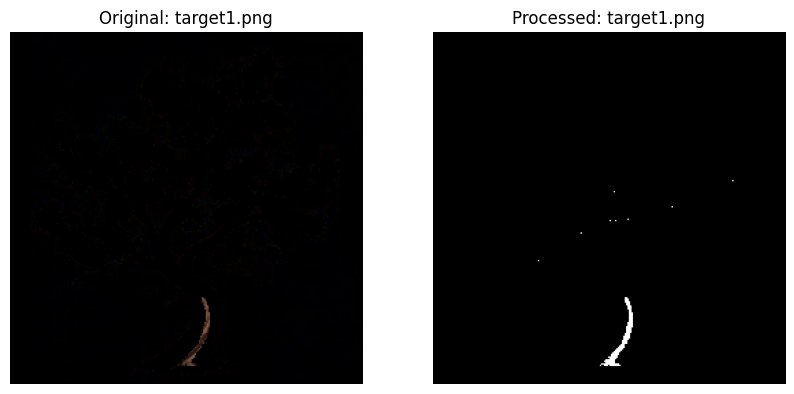

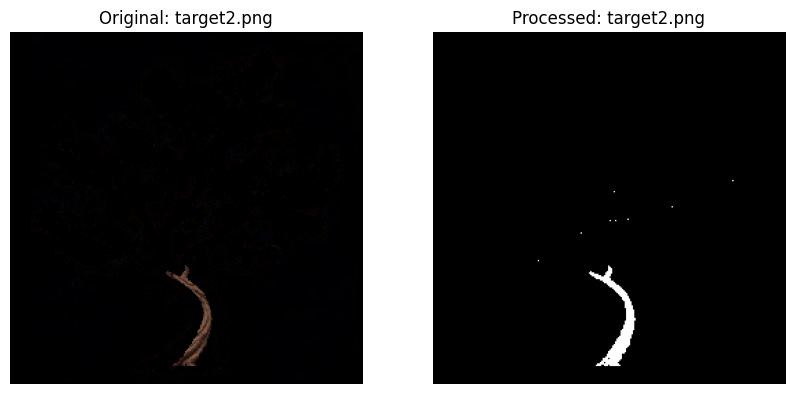

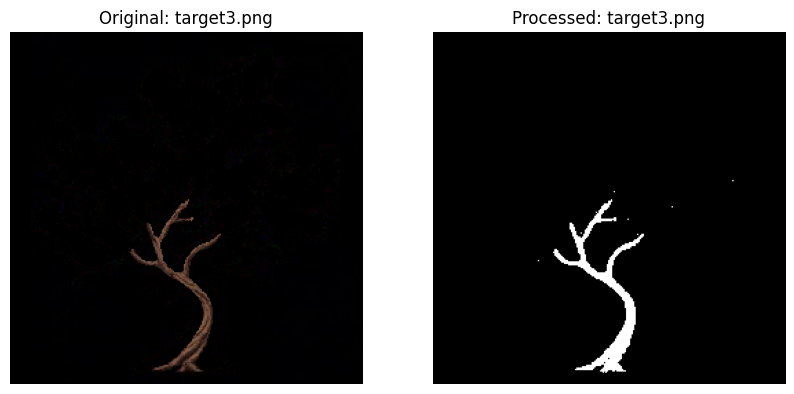

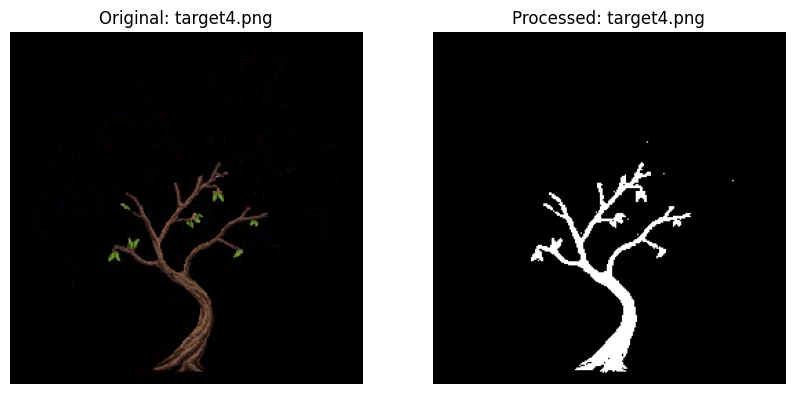

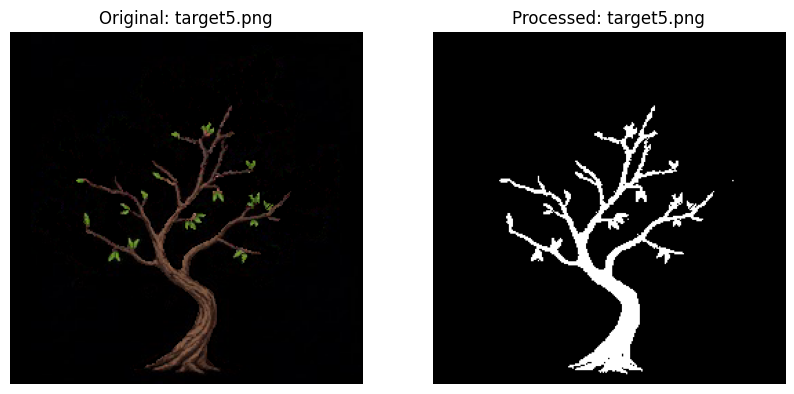

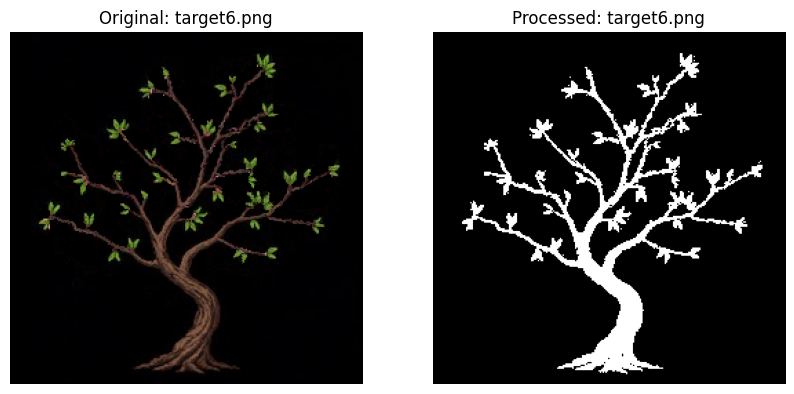

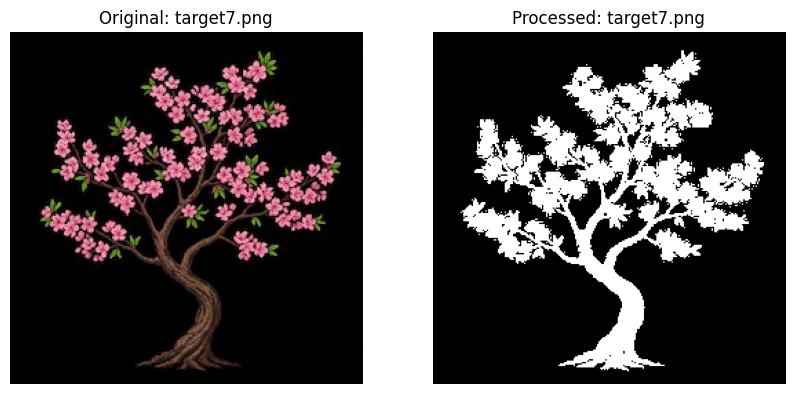

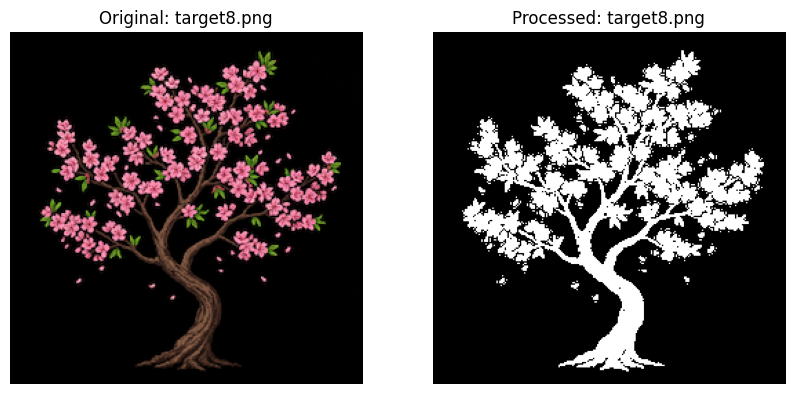

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load images from target1.png to target8.png
for i in range(1, 9):
    image_path = f'target{i}.png'
    image = Image.open(image_path).convert('RGB')

    # Convert image to numpy array
    data = np.array(image)

    # Create a mask for pixels where all RGB channels are below 15
    mask = (data[:, :, 0] < 25) & (data[:, :, 1] < 25) & (data[:, :, 2] < 25)

    # Create a new image where masked pixels are black and others are white
    new_data = np.ones_like(data) * 255  # Start with a white image
    new_data[mask] = [0, 0, 0]  # Set masked pixels to black

    # Convert back to an image
    new_image = Image.fromarray(new_data)

    # Create a figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    # Display original image
    ax1.imshow(image)
    ax1.axis('off')
    ax1.set_title(f'Original: {image_path}')
    
    # Display processed image
    ax2.imshow(new_image)
    ax2.axis('off')
    ax2.set_title(f'Processed: {image_path}')
    
    plt.show()
